# USDA portion coverage & recipe gram-resolution feasibility

Two analyses:

1. **USDA `food_portion` coverage** — how much of `usda.food` and `usda.food_4macro` have portion rows, and what share of portions are volume / mass / count.
2. **Recipe ingredient amount kinds** — on 100 RecipeNLG recipes (seed 42), classify lines with `portion_gram.resolve_quantity_fields` (rules parse + `amount_kind`) to estimate how much of the gram pipeline is mass-direct vs portion lookup vs unresolvable.

**Kernel cwd:** `Capstone/` project root (or `scratch/EDA/`). Requires `.env` Postgres credentials.

In [3]:
from __future__ import annotations

import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def resolve_capstone_root() -> Path:
    cwd = Path.cwd()
    for candidate in (cwd, cwd.parent, cwd.parent.parent):
        if (candidate / "scripts" / "db.py").is_file():
            return candidate
    raise FileNotFoundError("Run with kernel cwd = Capstone/ or scratch/EDA/")


ROOT = resolve_capstone_root()
SCRIPTS = ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from db import connect, load_dotenv
from portion_gram import (
    PORTION_INDEX_SQL,
    classify_food_portion_row,
    resolve_quantity_fields,
)
from sample_recipes import load_sampled_recipes

load_dotenv(ROOT / ".env")
pd.set_option("display.max_colwidth", 100)
print(f"Capstone root: {ROOT}")

Capstone root: /Users/danielcosta/Berkeley/Capstone


## 1. USDA table sizes & `food_portion` coverage

In [ ]:
COVERAGE_SQL = """
SELECT
  (SELECT COUNT(*) FROM usda.food) AS n_food,
  (SELECT COUNT(*) FROM usda.food_4macro) AS n_food_4macro,
  (SELECT COUNT(*) FROM usda.food_portion WHERE gram_weight > 0) AS n_portion_rows,
  (SELECT COUNT(DISTINCT fdc_id) FROM usda.food_portion WHERE gram_weight > 0) AS n_fdc_with_portion,
  (SELECT COUNT(*) FROM usda.food f
     WHERE EXISTS (
       SELECT 1 FROM usda.food_portion fp
       WHERE fp.fdc_id = f.fdc_id AND fp.gram_weight > 0
     )) AS n_food_with_portion,
  (SELECT COUNT(*) FROM usda.food_4macro f
     WHERE EXISTS (
       SELECT 1 FROM usda.food_portion fp
       WHERE fp.fdc_id = f.fdc_id AND fp.gram_weight > 0
     )) AS n_food_4macro_with_portion
"""

with connect() as conn:
    coverage = pd.read_sql(COVERAGE_SQL, conn)

row = coverage.iloc[0]
summary = pd.DataFrame([
    {
        "table": "usda.food",
        "total_foods": int(row.n_food),
        "with_portion": int(row.n_food_with_portion),
        "pct_with_portion": row.n_food_with_portion / row.n_food,
    },
    {
        "table": "usda.food_4macro",
        "total_foods": int(row.n_food_4macro),
        "with_portion": int(row.n_food_4macro_with_portion),
        "pct_with_portion": row.n_food_4macro_with_portion / row.n_food_4macro,
    },
])
summary["pct_with_portion"] = (summary["pct_with_portion"] * 100).round(2)
print(f"Distinct fdc_ids with gram_weight>0 portions: {int(row.n_fdc_with_portion):,}")
print(f"Total portion rows (gram_weight>0): {int(row.n_portion_rows):,}")
display(summary)

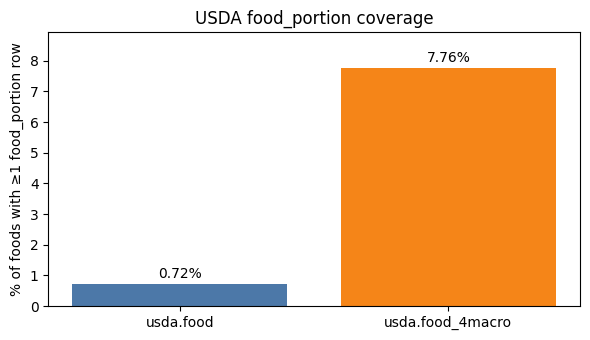

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(summary["table"], summary["pct_with_portion"], color=["#4c78a8", "#f58518"])
ax.set_ylabel("% of foods with ≥1 food_portion row")
ax.set_ylim(0, max(summary["pct_with_portion"]) * 1.15)
for i, pct in enumerate(summary["pct_with_portion"]):
    ax.text(i, pct + 0.2, f"{pct:.2f}%", ha="center", fontsize=10)
ax.set_title("USDA food_portion coverage")
plt.tight_layout()
plt.show()

## 2. Classify `food_portion` rows: volume vs mass vs count

Uses `classify_food_portion_row` from `scripts/portion_gram.py`, which searches **measure_unit.name**, **modifier**, and **portion_description** (in that order) until a unit/label is found — not just one column.

In [5]:
with connect() as conn:
    with conn.cursor() as cur:
        cur.execute(PORTION_INDEX_SQL)
        columns = [desc[0] for desc in cur.description]
        portion_rows = []
        for db_row in cur.fetchall():
            row = dict(zip(columns, db_row, strict=True))
            row["portion_kind"] = classify_food_portion_row(row)
            portion_rows.append(row)

portions_df = pd.DataFrame(portion_rows)
print(f"Loaded {len(portions_df):,} portion rows")
display(portions_df["portion_kind"].value_counts().to_frame("n_rows"))

Loaded 47,063 portion rows


,n_rows
portion_kind,
count,28567
volume,9183
mass,6828
other,2485


,pct_of_portion_rows,n_rows
portion_kind,,
count,60.70,28567
volume,19.51,9183
mass,14.51,6828
other,5.28,2485


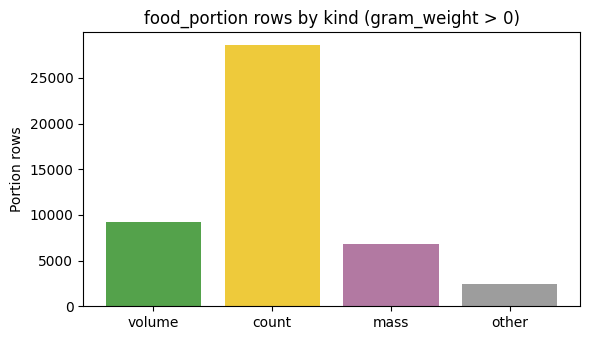

In [6]:
portion_pct = (
    portions_df["portion_kind"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("pct_of_portion_rows")
    .to_frame()
)
portion_pct["n_rows"] = portions_df["portion_kind"].value_counts()
display(portion_pct.sort_values("pct_of_portion_rows", ascending=False))

fig, ax = plt.subplots(figsize=(6, 3.5))
order = ["volume", "count", "mass", "other"]
counts = [portion_pct.loc[k, "n_rows"] if k in portion_pct.index else 0 for k in order]
ax.bar(order, counts, color=["#54a24b", "#eeca3b", "#b279a2", "#9d9d9d"])
ax.set_ylabel("Portion rows")
ax.set_title("food_portion rows by kind (gram_weight > 0)")
plt.tight_layout()
plt.show()

## 3. Per-food portion capabilities

Among foods with at least one `food_portion` row, what share has volume, mass, and/or count portions?

In [7]:
food_kinds = (
    portions_df.groupby("fdc_id")["portion_kind"]
    .apply(lambda s: set(s))
    .rename("kinds")
    .reset_index()
)
n_foods_with_portion = len(food_kinds)

for kind in ("volume", "mass", "count"):
    food_kinds[f"has_{kind}"] = food_kinds["kinds"].map(lambda s: kind in s)

food_kind_summary = pd.DataFrame({
    "kind": ["volume", "mass", "count"],
    "n_foods": [
        int(food_kinds["has_volume"].sum()),
        int(food_kinds["has_mass"].sum()),
        int(food_kinds["has_count"].sum()),
    ],
})
food_kind_summary["pct_of_foods_with_portion"] = (
    food_kind_summary["n_foods"] / n_foods_with_portion * 100
).round(2)
display(food_kind_summary)

# Overlap among foods that have any portion row
combo = Counter()
for kinds in food_kinds["kinds"]:
    key = "+".join(k for k in ("volume", "mass", "count") if k in kinds) or "other_only"
    combo[key] += 1
combo_df = (
    pd.Series(combo, name="n_foods")
    .sort_values(ascending=False)
    .to_frame()
)
combo_df["pct"] = (combo_df["n_foods"] / n_foods_with_portion * 100).round(2)
print("Portion-kind combinations per food (foods with ≥1 portion row):")
display(combo_df.head(12))

,kind,n_foods,pct_of_foods_with_portion
0,volume,7598,49.91
1,mass,4932,32.40
2,count,10205,67.03


Portion-kind combinations per food (foods with ≥1 portion row):


,n_foods,pct
volume+count,3917,25.73
count,3541,23.26
volume,2468,16.21
mass+count,1994,13.10
mass,1725,11.33
volume+mass+count,753,4.95
volume+mass,460,3.02
other_only,366,2.40


In [8]:
# food_4macro subset: portion capability among macro-complete catalog
from load_food_4macro import load_food_4macro

food_4macro = load_food_4macro()
food_4_ids = set(food_4macro["fdc_id"].astype(int))
food_kinds_4 = food_kinds[food_kinds["fdc_id"].isin(food_4_ids)].copy()
n_4 = len(food_kinds_4)

food_4_summary = pd.DataFrame({
    "kind": ["volume", "mass", "count"],
    "n_foods_in_food_4macro": [
        int(food_kinds_4["has_volume"].sum()),
        int(food_kinds_4["has_mass"].sum()),
        int(food_kinds_4["has_count"].sum()),
    ],
})
food_4_summary["pct_of_food_4macro"] = (
    food_4_summary["n_foods_in_food_4macro"] / len(food_4_ids) * 100
).round(2)
food_4_summary["pct_of_food_4macro_with_portion"] = (
    food_4_summary["n_foods_in_food_4macro"] / max(n_4, 1) * 100
).round(2)
print(f"food_4macro foods with any portion row: {n_4:,} / {len(food_4_ids):,}")
display(food_4_summary)

food_4macro foods with any portion row: 7,526 / 96,996


,kind,n_foods_in_food_4macro,pct_of_food_4macro,pct_of_food_4macro_with_portion
0,volume,2997,3.09,39.82
1,mass,3758,3.87,49.93
2,count,3453,3.56,45.88


## 4. Recipe ingredient amount kinds (100 recipes, seed 42)

Parses each ingredient line with `resolve_quantity_fields` (`recipe_parse_rules` + `amount_kind.classify_amount_kind`).

| Kind | Gram pipeline |
|------|----------------|
| **mass** | Direct `unit_convert` to grams |
| **volume** | Needs `food_portion` volume row for matched fdc_id |
| **count** | Needs `food_portion` count row for matched fdc_id |
| **unmeasurable** / **unknown** | Unresolvable without LLM or heuristics |

In [ ]:
N_RECIPES = 100
SEED = 42

_recipes, eval_df, recipe_ids = load_sampled_recipes(n=N_RECIPES, seed=SEED)
print(f"Recipes: {len(recipe_ids):,}  Ingredient lines: {len(eval_df):,}")

parsed_rows: list[dict] = []
for row in eval_df.itertuples(index=False):
    ingredient = str(row.ingredient)
    fields = resolve_quantity_fields(ingredient, method="rules")
    parsed_rows.append({
        "recipe_id": int(row.recipe_id),
        "ingredient_idx": int(row.ingredient_idx),
        "ingredient_raw": ingredient,
        "quantity": fields.get("quantity"),
        "unit": fields.get("unit"),
        "name": fields.get("name"),
        "parse_status": fields.get("parse_status"),
        "amount_kind": fields.get("amount_kind"),
        "resolvable": fields.get("resolvable"),
    })

recipe_parse_df = pd.DataFrame(parsed_rows)
recipe_parse_df["pipeline_bucket"] = recipe_parse_df["amount_kind"].map({
    "mass": "mass (direct convert)",
    "volume": "volume (needs portion)",
    "count": "count (needs portion)",
    "unmeasurable": "unresolvable",
    "unknown": "unresolvable",
})
display(recipe_parse_df.head(8))

In [ ]:
n_lines = len(recipe_parse_df)
kind_counts = recipe_parse_df["amount_kind"].value_counts()
kind_pct = (kind_counts / n_lines * 100).round(2)

recipe_summary = pd.DataFrame({"n_lines": kind_counts, "pct_lines": kind_pct})
display(recipe_summary)

resolvable_pct = recipe_parse_df["resolvable"].mean() * 100
needs_portion_pct = recipe_parse_df["amount_kind"].isin(["volume", "count"]).mean() * 100
print(f"Resolvable (mass+volume+count): {resolvable_pct:.2f}%")
print(f"Needs food_portion lookup (volume+count): {needs_portion_pct:.2f}%")
print(f"Unresolvable (unmeasurable+unknown): {(100 - resolvable_pct):.2f}%")

,n_lines,pct_lines
amount_kind,,
volume,4930,56.32
count,2349,26.83
unmeasurable,775,8.85
mass,621,7.09
unknown,79,0.90


Resolvable (mass+volume+count): 90.24%
Needs food_portion lookup (volume+count): 83.15%
Unresolvable (unmeasurable+unknown): 9.76%


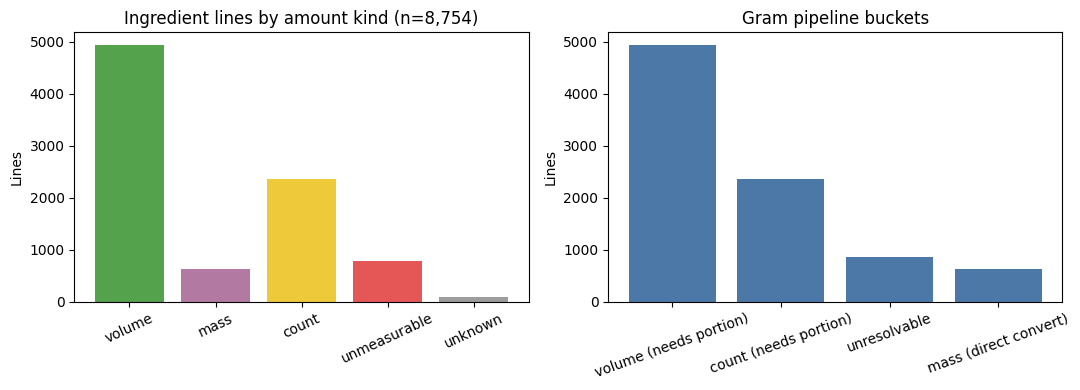

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_order = ["volume", "mass", "count", "unmeasurable", "unknown"]
plot_colors = ["#54a24b", "#b279a2", "#eeca3b", "#e45756", "#9d9d9d"]
vals = [kind_counts.get(k, 0) for k in plot_order]
axes[0].bar(plot_order, vals, color=plot_colors)
axes[0].set_title(f"Ingredient lines by amount kind (n={n_lines:,})")
axes[0].set_ylabel("Lines")
axes[0].tick_params(axis="x", rotation=25)

bucket_counts = recipe_parse_df["pipeline_bucket"].value_counts()
axes[1].bar(bucket_counts.index, bucket_counts.values, color="#4c78a8")
axes[1].set_title("Gram pipeline buckets")
axes[1].set_ylabel("Lines")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
# Sample unresolvable lines for manual review
unresolvable = recipe_parse_df[
    recipe_parse_df["amount_kind"].isin(["unmeasurable", "unknown"])
].copy()
print(f"Unresolvable lines: {len(unresolvable):,}")
display(
    unresolvable[["ingredient_raw", "quantity", "unit", "name", "parse_status", "amount_kind"]]
    .drop_duplicates("ingredient_raw")
    .head(20)
)

Unresolvable lines: 854


,ingredient_raw,quantity,unit,name,parse_status,amount_kind
18,mixed nuts,NaN,None,mixed nuts,no_quantity,unmeasurable
25,dash of garlic powder,NaN,None,dash of garlic powder,no_quantity,unmeasurable
62,Worcestershire sauce to taste,NaN,None,Worcestershire sauce to taste,no_quantity,unmeasurable
63,"garlic salt, salt and pepper to taste",NaN,None,"garlic salt, salt and pepper to taste",no_quantity,unmeasurable
71,salt and pepper,NaN,None,salt and pepper,no_quantity,unmeasurable
104,dash of hot pepper sauce,NaN,None,dash of hot pepper sauce,no_quantity,unmeasurable
117,chopped pecans,NaN,None,chopped pecans,no_quantity,unmeasurable
133,"large bag Doritos, broken",NaN,None,"large bag Doritos, broken",no_quantity,unmeasurable
154,salt to taste,NaN,None,salt to taste,no_quantity,unmeasurable
168,"salt, pepper and garlic powder to taste",NaN,None,"salt, pepper and garlic powder to taste",no_quantity,unmeasurable


## 6. End-to-end portion pipeline feasibility (1000 recipes, seed 42)

Artifacts under `scratch/EDA/portion_feasibility_1000/` (from `scripts/portion_pipeline_feasibility.py`):

| File | Contents |
|------|----------|
| `amount_classification.parquet` | Rules + LLM amount_kind per ingredient line |
| **`judge_matches_raw.parquet`** | **LLM fdc judge results** (primary match output) |
| `pipeline_matches.parquet` | Judge + rules/LM gram enrichment |
| `feasibility_report.json` | Aggregated rates |

Phases: amount kind → portion-aware LLM fdc match → USDA portion gram resolution (rules, then LLM portion-row pick).

In [ ]:
import json
from pathlib import Path

FEAS_DIR = ROOT / "scratch" / "EDA" / "portion_feasibility_1000"
JUDGE_PATH = FEAS_DIR / "judge_matches_raw.parquet"
AMOUNT_PATH = FEAS_DIR / "amount_classification.parquet"
PIPELINE_PATH = FEAS_DIR / "pipeline_matches.parquet"
REPORT_PATH = FEAS_DIR / "feasibility_report.json"

JUDGE_DISPLAY_COLS = [
    "recipe_id",
    "ingredient_idx",
    "ingredient",
    "amount_kind",
    "quantity",
    "unit",
    "llm_fdc_id",
    "llm_description",
    "llm_certainty",
    "llm_rationale",
    "llm_agrees_with_staged",
    "llm_abstained",
    "llm_error",
    "staged_fdc_id",
    "retrieval_tier",
    "grams",
    "grams_status",
]

if not JUDGE_PATH.is_file():
    print(
        "No judge results yet. Run:\n"
        "  uv run python scripts/portion_pipeline_feasibility.py --n-recipes 1000 --seed 42"
    )
else:
    judge_df = pd.read_parquet(JUDGE_PATH)
    n = len(judge_df)
    n_fdc = int(judge_df["llm_fdc_id"].notna().sum())
    n_abstain = int(judge_df.get("llm_abstained", pd.Series(False, index=judge_df.index)).sum())
    n_err = int(judge_df["llm_error"].notna().sum()) if "llm_error" in judge_df.columns else 0

    print(f"Judge results: {JUDGE_PATH}")
    print(f"  lines: {n:,}  |  fdc matched: {n_fdc:,} ({100 * n_fdc / n:.1f}%)")
    print(f"  abstained: {n_abstain:,}  |  errors: {n_err:,}")

    if AMOUNT_PATH.is_file():
        amount_df = pd.read_parquet(AMOUNT_PATH)
        judge_view = judge_df.merge(
            amount_df[
                ["recipe_id", "ingredient_idx", "amount_kind_final", "needs_portion"]
            ],
            on=["recipe_id", "ingredient_idx"],
            how="left",
        )
    else:
        judge_view = judge_df.copy()

    if REPORT_PATH.is_file():
        report = json.loads(REPORT_PATH.read_text())
        display(
            pd.Series(
                {
                    "fdc_match_rate_all": report.get("fdc_match_rate_all"),
                    "fdc_and_gram_rate_all": report.get("fdc_and_gram_rate_all"),
                    "fdc_and_gram_rate_needs_portion": report.get(
                        "fdc_and_gram_rate_needs_portion"
                    ),
                    "judge_error_count": report.get("judge_error_count"),
                }
            ).to_frame("rate")
        )

    print("\n### Judge summary by amount_kind")
    display(
        judge_view.groupby("amount_kind", dropna=False)
        .agg(
            n=("ingredient", "count"),
            fdc_matched=("llm_fdc_id", lambda s: s.notna().sum()),
            abstained=("llm_abstained", "sum"),
            errors=("llm_error", lambda s: s.notna().sum()),
            avg_certainty=("llm_certainty", "mean"),
        )
        .assign(
            fdc_rate=lambda d: (100 * d["fdc_matched"] / d["n"]).round(1),
            avg_certainty=lambda d: d["avg_certainty"].round(2),
        )
    )

    if n_err:
        print("\n### Judge errors")
        err_types = (
            judge_view.loc[judge_view["llm_error"].notna(), "llm_error"]
            .astype(str)
            .str.split(":", n=1)
            .str[0]
            .value_counts()
        )
        display(err_types.to_frame("count"))
        display(
            judge_view.loc[judge_view["llm_error"].notna(), JUDGE_DISPLAY_COLS]
            .head(20)
        )

    print("\n### Sample successful matches")
    ok = judge_view[judge_view["llm_fdc_id"].notna()]
    display(ok[JUDGE_DISPLAY_COLS].head(25))

    print("\n### Sample abstentions (no fdc pick)")
    abst = judge_view[judge_view["llm_abstained"].fillna(False)]
    if len(abst):
        display(abst[JUDGE_DISPLAY_COLS].head(15))

    # Full judge table (browse); omit verbose prompt/response columns
    drop_cols = {"prompt", "response", "system_prompt", "relevant_steps"}
    judge_browse = judge_view[[c for c in judge_view.columns if c not in drop_cols]]
    print(f"\n### All judge rows ({len(judge_browse):,})")
    display(judge_browse)

    # Enriched pipeline output (optional; may be stale if judge was re-run)
    if PIPELINE_PATH.is_file():
        pipeline_df = pd.read_parquet(PIPELINE_PATH)
        pipeline_fdc = int(pipeline_df["llm_fdc_id"].notna().sum())
        if pipeline_fdc != n_fdc:
            print(
                f"\nNote: pipeline_matches.parquet has {pipeline_fdc} fdc matches vs "
                f"{n_fdc} in judge_matches_raw — re-run script without --force-judging "
                "to refresh enrichment."
            )
        elif "rules_grams" in pipeline_df.columns:
            print("\n### Pipeline enrichment (needs_portion lines)")
            if "needs_portion" in pipeline_df.columns:
                needs = pipeline_df[pipeline_df["needs_portion"]].copy()
                breakdown = pd.DataFrame(
                    {
                        "fdc_matched": needs["llm_fdc_id"].notna(),
                        "usda_portion_row": needs["usda_portion_available"].fillna(False),
                        "rules_grams": needs["rules_grams"].notna(),
                        "final_grams": needs["grams"].notna(),
                        "llm_portion_rescue": needs["portion_resolved_by_llm"].fillna(
                            False
                        ),
                    }
                ).mean().mul(100).round(1)
                display(breakdown.to_frame("pct_of_needs_portion"))

## 5. Takeaways

- **`food_4macro`** is the practical matching catalog; only ~8% of those foods have any `food_portion` row, but that is far higher than all of `usda.food` (~0.7%).
- Portion rows skew **count** then **volume**; **mass** labels are a smaller share — recipe mass units mostly convert without USDA portions.
- On 100 recipes (seed 42), **~92%** of lines classify as mass/volume/count under rules parse; **volume** dominates. Full gram resolution still depends on **fdc match + portion row availability** for volume/count lines.
- Multi-column portion search (`measure_unit` → `modifier` → `portion_description`) drops unclassified USDA portion rows from ~8% to **~5%**.
- **Unresolvable** lines (`unmeasurable` + `unknown`) are the main gap — LLM parse, better unit normalization, or default portion assumptions may be needed.